In [6]:
PREDICTION_DATETIME = "20260915_163546"

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.ps_dare.paths import solve_path

PREDICTIONS_DIR = solve_path("data/weekly/predictions")
PREDICTION_DATASETS = ("general_giustiniani", "general_pediatrico")

standardised_plot = False

def load_predictions(dataset, prediction_datetime):
    paths = sorted(
        (PREDICTIONS_DIR / dataset).glob(f"*_{prediction_datetime}.csv")
    )
    if not paths:
        raise FileNotFoundError(
            f"No predictions found for {dataset!r} at {prediction_datetime}"
        )
    frame = pd.concat((pd.read_csv(path) for path in paths), ignore_index=True)
    # Forced-order baselines can use the same `drivers_used` value as selected models.
    return frame.loc[frame["driver_kind"].ne("forced")].copy()


df_giustiniani, df_pediatrico = (
    load_predictions(dataset, PREDICTION_DATETIME)
    for dataset in PREDICTION_DATASETS
)

# Use the same baseline prediction artifacts selected in Figure 1.
df_giustiniani_baseline = pd.read_csv(
    PREDICTIONS_DIR
    / "general_giustiniani/general_giustiniani_baseline_weekly_model_001_20260918_152019.csv"
)
df_pediatrico_baseline = pd.read_csv(
    PREDICTIONS_DIR
    / "general_pediatrico/general_pediatrico_baseline_weekly_model_002_20260918_152019.csv"
)

date_columns = ["date", "date_start_training", "date_end_training", "date_end_testing"]
for frame in (
    df_giustiniani, df_pediatrico,
    df_giustiniani_baseline, df_pediatrico_baseline,
):
    frame[date_columns] = frame[date_columns].apply(pd.to_datetime)

print(f"Loaded prediction run: {PREDICTION_DATETIME}")

Loaded prediction run: 20260915_163546


In [7]:
giustiniani_drivers = [
    "none",
    "humidex",
    "frost",
    "indoor_wet_bulb",
]
pediatrico_drivers = [
    "none",
    "humidex",
    "frost",
    "indoor_wet_bulb",
]
all_drivers = list(dict.fromkeys(
    driver for driver in giustiniani_drivers + pediatrico_drivers
    if driver != "none"
))

driver_colors = {
    "none": "tab:green",
    "humidex": "tab:blue",
    "frost": "tab:orange",
    "indoor_wet_bulb": "tab:purple",
    "hu": "tab:red",
    "summer_days": "tab:brown",
}
driver_labels = {
    "none": "No driver",
    "humidex": "Humidex",
    "frost": "Frost",
    "indoor_wet_bulb": "Indoor wet bulb",
    "hu": "HU",
    "summer_days": "Summer days",
}

available_drivers = sorted(
    (set(df_giustiniani["drivers_used"]) | set(df_pediatrico["drivers_used"]))
    - {"none"}
)
for dataset, frame, drivers in (
    (PREDICTION_DATASETS[0], df_giustiniani, giustiniani_drivers),
    (PREDICTION_DATASETS[1], df_pediatrico, pediatrico_drivers),
):
    missing_drivers = sorted(set(drivers) - set(frame["drivers_used"]))
    if missing_drivers:
        raise ValueError(f"Drivers missing from {dataset!r}: {missing_drivers}")

print(f"Total available drivers: {len(available_drivers)}")
print(f"Giustiniani prediction drivers: {giustiniani_drivers}")
print(f"Pediatrico prediction drivers: {pediatrico_drivers}")

Total available drivers: 18
Giustiniani prediction drivers: ['none', 'humidex', 'frost', 'indoor_wet_bulb']
Pediatrico prediction drivers: ['none', 'humidex', 'frost', 'indoor_wet_bulb']


In [8]:
def score_predictions(frame):
    test = (
        frame.loc[frame["phase"].eq("testing"), ["date", "n_accesses", "prediction"]]
        .dropna(subset=["n_accesses", "prediction"])
        .sort_values("date")
    )
    absolute_errors = (test["prediction"] - test["n_accesses"]).abs()
    nonzero_actuals = test["n_accesses"].ne(0)
    actual_direction = np.sign(test["n_accesses"].diff())
    predicted_direction = np.sign(test["prediction"].diff())
    return {
        "MAE": absolute_errors.mean(),
        "MAPE (%)": (
            absolute_errors[nonzero_actuals]
            / test.loc[nonzero_actuals, "n_accesses"].abs()
        ).mean() * 100,
        "Directional accuracy (%)": (
            actual_direction.iloc[1:].eq(predicted_direction.iloc[1:]).mean() * 100
        ),
        "AE (total)": absolute_errors.sum(),
    }

metric_rows = []
for hospital, frame, drivers, baseline in (
    ("Giustiniani", df_giustiniani, giustiniani_drivers, df_giustiniani_baseline),
    ("Pediatrico", df_pediatrico, pediatrico_drivers, df_pediatrico_baseline),
):
    for driver in drivers:
        driver_frame = frame.loc[frame["drivers_used"].eq(driver)]
        metric_rows.append(
            {"Hospital": hospital, "Model": driver_labels[driver], **score_predictions(driver_frame)}
        )
    metric_rows.append(
        {"Hospital": hospital, "Model": "Baseline", **score_predictions(baseline)}
    )

driver_metrics = pd.DataFrame(metric_rows).set_index(["Hospital", "Model"])
driver_metrics.round(2).to_csv(solve_path("graphs/fig2_model_metrics.csv"))
driver_metrics.round(2)

MAE  MAPE (%)  Directional accuracy (%)  \
Hospital    Model                                                        
Giustiniani No driver        60.62      3.32                     38.85   
            Humidex          60.61      3.32                     38.85   
            Frost            60.66      3.33                     38.46   
            Indoor wet bulb  60.61      3.32                     38.85   
            Baseline         62.17      3.40                     36.15   
Pediatrico  No driver        35.54      7.09                     50.38   
            Humidex          35.86      7.16                     50.00   
            Frost            37.72      7.56                     49.62   
            Indoor wet bulb  37.54      7.52                     49.62   
            Baseline         36.31      7.25                     48.08   

                             AE (total)  
Hospital    Model                        
Giustiniani No driver          15822.24  
            Humidex            15818.62  
            Frost              15831.30  
            Indoor wet bulb    15818.49  
            Baseline           16227.00  
Pediatrico  No driver           9276.72  
            Humidex             9358.47  
            Frost               9845.62  
            Indoor wet bulb     9796.85  
            Baseline            9477.00

In [9]:
pd.DataFrame(
    {"Driver": available_drivers},
    index=pd.RangeIndex(1, len(available_drivers) + 1, name="#"),
)

,Driver
#,
1,CO_mean
2,CO_peak
3,NO2_mean
4,NO2_peak
5,SO2_mean
6,SO2_peak
7,abs_hu
8,frost
9,heating_degree_days


/var/folders/pj/3l0440l51_9660gzkl7_1hwm0000gn/T/ipykernel_90515/2129832532.py:122: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


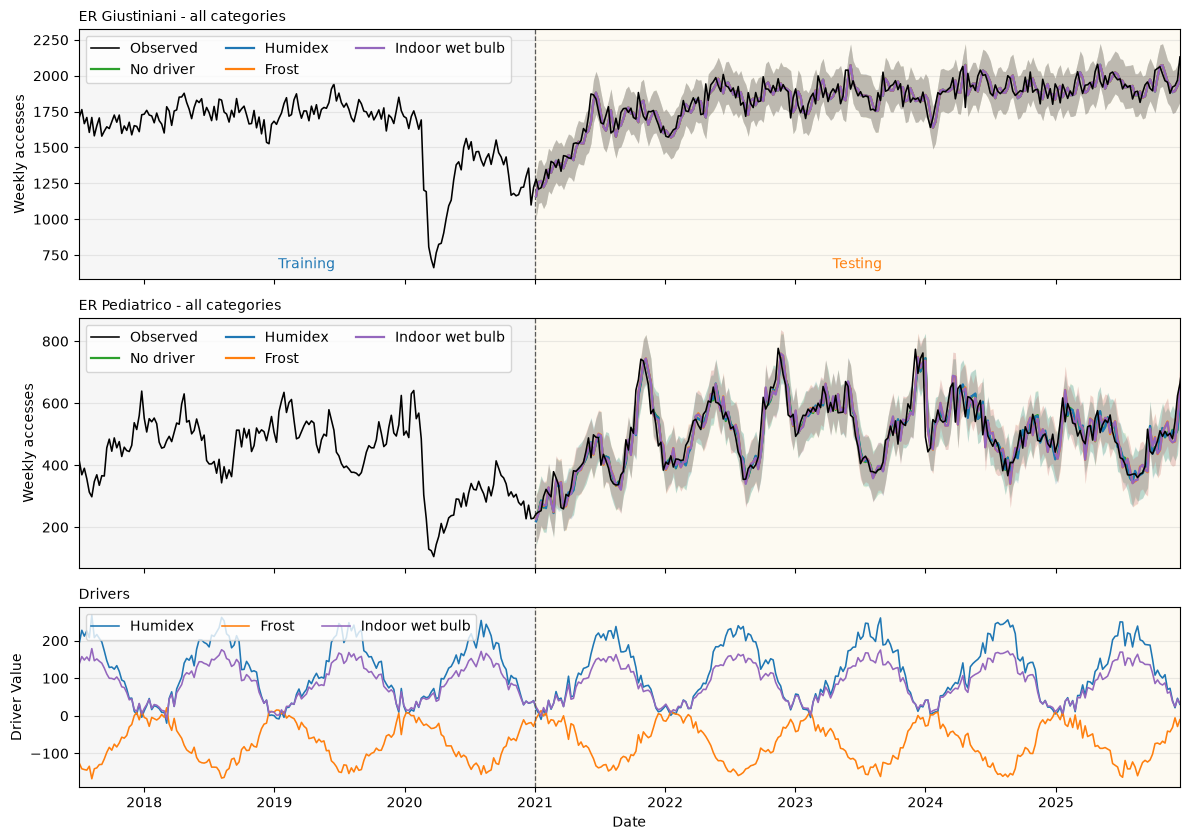

In [10]:
plot_font_size = 10
plt.rcParams.update(
    {
        "font.size": plot_font_size,
        "axes.titlesize": plot_font_size,
        "axes.labelsize": plot_font_size,
        "xtick.labelsize": plot_font_size,
        "ytick.labelsize": plot_font_size,
        "legend.fontsize": plot_font_size,
        "figure.titlesize": plot_font_size,
        "figure.labelsize": plot_font_size,
    }
)


def model_rows(frame, driver):
    rows = frame.loc[frame["drivers_used"].eq(driver)].sort_values("date")
    if rows.empty:
        raise ValueError(f"No prediction found for {driver!r}")
    return rows


def plot_outcome(ax, frame, drivers, title):
    # Observations are identical across models; the no-driver run has the full test span.
    observed = model_rows(frame, "none")
    observed = observed.loc[observed["phase"].isin(["training", "testing"])]
    ax.plot(
        observed["date"], observed["n_accesses"], color="black",
        linewidth=1.15, label="Observed", zorder=4,
    )

    for driver in drivers:
        forecast = model_rows(frame, driver)
        forecast = forecast.loc[forecast["phase"].eq("testing")].dropna(
            subset=["prediction", "prediction_lower_bound", "prediction_upper_bound"]
        )
        color = driver_colors[driver]
        label = driver_labels[driver]
        ax.plot(
            forecast["date"], forecast["prediction"], color=color,
            linewidth=1.6, label=label, zorder=3,
        )
        ax.fill_between(
            forecast["date"], forecast["prediction_lower_bound"],
            forecast["prediction_upper_bound"], color=color, alpha=0.16,
            linewidth=0, zorder=2,
        )

    # ax.set_title(title, loc="left", fontweight="bold")
    ax.set_title(title, loc="left")
    ax.set_ylabel("Weekly accesses")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", ncols=3)


training_start = df_giustiniani["date_start_training"].iloc[0]
training_end = df_giustiniani["date_end_training"].iloc[0]
testing_start = min(
    frame.loc[frame["phase"].eq("testing"), "date"].min()
    for frame in (df_giustiniani, df_pediatrico)
)
zoom_start = testing_start - pd.DateOffset(months=6)
testing_end = max(
    model_rows(df_giustiniani, driver).loc[lambda x: x["phase"].eq("testing"), "date"].max()
    for driver in giustiniani_drivers
)
testing_end = max(
    testing_end,
    *(model_rows(df_pediatrico, driver).loc[lambda x: x["phase"].eq("testing"), "date"].max()
      for driver in pediatrico_drivers),
)
testing_end = min(testing_end, pd.Timestamp("2025-12-15"))

fig, axes = plt.subplots(
    3, 1, figsize=(12, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 0.72]}, constrained_layout=True,
)

plot_outcome(axes[0], df_giustiniani, giustiniani_drivers, "ER Giustiniani - all categories")
plot_outcome(axes[1], df_pediatrico, pediatrico_drivers, "ER Pediatrico - all categories")

# Standardisation lets drivers with different units share one readable panel.
for driver in all_drivers:
    values = model_rows(df_giustiniani, driver)
    values = values.loc[values["phase"].isin(["training", "testing"]), ["date", "driver_value"]]
    values = values.dropna(subset=["driver_value"])
    standardised = (values["driver_value"] - values["driver_value"].mean()) / values["driver_value"].std()
    if standardised_plot:
        driver_to_plot=standardised
    else:
        driver_to_plot=values["driver_value"]
    axes[2].plot(
        values["date"], driver_to_plot, color=driver_colors[driver],
        linewidth=1.15, label=driver_labels[driver],
    )

# axes[2].set_title("Drivers", loc="left", fontweight="bold")
axes[2].set_title("Drivers", loc="left")
axes[2].set_ylabel("Standardised value" if standardised_plot else "Driver Value")
axes[2].set_xlabel("Date")
axes[2].grid(axis="y", alpha=0.25)
axes[2].legend(loc="upper left", ncols=3)

for ax in axes:
    ax.axvspan(training_start, training_end, color="lightgray", alpha=0.2, zorder=0)
    ax.axvspan(training_end, testing_end, color="#E69F00", alpha=0.05, zorder=0)
    ax.axvline(training_end, color="0.35", linestyle="--", linewidth=0.9)
    # Keep a short training lead-in and devote most horizontal space to testing.
    ax.set_xlim(zoom_start, testing_end)

axes[0].text(
    zoom_start + (training_end - zoom_start) / 2, 0.03, "Training",
    transform=axes[0].get_xaxis_transform(), ha="center", va="bottom", color="tab:blue",
)
axes[0].text(
    training_end + (testing_end - training_end) / 2, 0.03, "Testing",
    transform=axes[0].get_xaxis_transform(), ha="center", va="bottom", color="tab:orange",
)
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# plt.xlim(zoom_start, pd.to_datetime("2026-12-01"))
plt.tight_layout()
plt.savefig(
    solve_path("graphs/fig2.pdf"),
    bbox_inches="tight", pad_inches=0.01,
)
plt.show()
